# Assignment
Please answer the questions below based on the data provided:

* Plot daily sales for all 50 weeks.
* It looks like there has been a sudden change in daily sales. What date did it occur?
* Is the change in daily sales at the date you selected statistically significant? If so, what is the p-value?
* Does the data suggest that the change in daily sales is due to a shift in the proportion of male-vs-female customers? Please use plots to support your answer (a rigorous statistical analysis is not necessary).
* Assume a given day is divided into four dayparts: night (12:00AM - 6:00AM), morning (6:00AM - 12:00PM), afternoon (12:00PM - 6:00PM) and evening (6:00PM - 12:00AM). What is the percentage of sales in each daypart over all 50 weeks?

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/biswasbarsha/sales-data-analysis-dataset/datasets/sales_week_starting_2013-02-25.csv
/kaggle/input/datasets/biswasbarsha/sales-data-analysis-dataset/datasets/sales_week_starting_2013-03-11.csv
/kaggle/input/datasets/biswasbarsha/sales-data-analysis-dataset/datasets/sales_week_starting_2013-06-03.csv
/kaggle/input/datasets/biswasbarsha/sales-data-analysis-dataset/datasets/sales_week_starting_2013-08-26.csv
/kaggle/input/datasets/biswasbarsha/sales-data-analysis-dataset/datasets/sales_week_starting_2012-12-17.csv
/kaggle/input/datasets/biswasbarsha/sales-data-analysis-dataset/datasets/sales_week_starting_2013-09-09.csv
/kaggle/input/datasets/biswasbarsha/sales-data-analysis-dataset/datasets/sales_week_starting_2013-05-27.csv
/kaggle/input/datasets/biswasbarsha/sales-data-analysis-dataset/datasets/sales_week_starting_2012-12-24.csv
/kaggle/input/datasets/biswasbarsha/sales-data-analysis-dataset/datasets/sales_week_starting_2013-06-17.csv
/kaggle/input/datasets/biswa

# Data Exploration

In [4]:
import glob 

# get all filenames under the data directory 
l = [pd.read_csv(filename) for filename in glob.glob("/kaggle/input/datasets/biswasbarsha/sales-data-analysis-dataset/datasets/*.csv")]

# check the list size to understand how many files will be read
len(l)

50

We have 50 files under the /data directory. So, we should have a list including 50 filenames.

In [5]:
import pandas as pd
import glob

# 1. Get a list of all your filenames (assuming they are CSVs in one folder)
file_paths = glob.glob('/kaggle/input/datasets/biswasbarsha/sales-data-analysis-dataset/datasets/*.csv')

# 2. Load all files into a list
df_list = [pd.read_csv(f) for f in file_paths]

# 3. Combine them all at once
combined_df = pd.concat(df_list, axis=0, ignore_index=True)

The instructions say the dataset includes two columns. Let's check our dataset.

In [6]:
combined_df.columns

Index(['sale_time', 'purchaser_gender'], dtype='object')

In [7]:
combined_df.shape

(204329, 2)

It is consistent with what was given to us in the overview section. By counting the sale entries for each day, we can obtain the sales amount for each day. Then, we can analyze the sales of the company. We will obtain the sales amount in a few steps. To begin with, we'll extract the sale day (year - month - day) from a complete timestamp (year - month - day hour - second - millisecond). We need to convert the sale_time column datatype to DateTime since pandas library provides several functions to conveniently manipulate timestamps.

In [8]:
combined_df['sale_time'] = pd.to_datetime(combined_df['sale_time'])
combined_df['Date'] = combined_df['sale_time'].dt.date
combined_df['Time'] = combined_df['sale_time'].dt.time

In [9]:
combined_df.head()

,sale_time,purchaser_gender,Date,Time
0,2013-02-25 00:40:45,male,2013-02-25,00:40:45
1,2013-02-25 00:56:52,male,2013-02-25,00:56:52
2,2013-02-25 01:18:00,female,2013-02-25,01:18:00
3,2013-02-25 01:20:00,male,2013-02-25,01:20:00
4,2013-02-25 01:45:08,female,2013-02-25,01:45:08


In [10]:
#Check for any null value
combined_df.isnull().sum()

sale_time           0
purchaser_gender    0
Date                0
Time                0
dtype: int64

Now, we can get the day by flooring the timestamp to the closest day. After that, we will group the sales entries by days with the groupby( ) function. Then we will count the entries in each group (which are the sale days in our case) with size( ), which gives us the sales amount for each day. Groupby objects use the given column as an index. As the last step, we will reformat the dataset with the _resetindex( ) function to get rid of sale day indexes.

In [11]:
daily_sales_df = combined_df['sale_time'].groupby(combined_df['sale_time'].dt.floor('d')).size().reset_index(name='sales amount')
daily_sales_df.rename(columns={'sale_time': 'sale_day'}, inplace=True)
daily_sales_df.head()

,sale_day,sales amount
0,2012-10-01,514
1,2012-10-02,482
2,2012-10-03,499
3,2012-10-04,546
4,2012-10-05,476


We continue to comprehend our dataset with some statistical metrics. describe( ) function provide us with the main statistical metrics for columns.

In [12]:
daily_sales_df['sales amount'].describe()

count    350.000000
mean     583.797143
std      105.152783
min      401.000000
25%      496.000000
50%      546.000000
75%      688.750000
max      801.000000
Name: sales amount, dtype: float64

The output says we have 350 different days in the dataset, which is aligned with our expectations since we already know the given data includes 50 weeks (50 x 7 = 350 days). The mean of sales amount column is around 583, which means the mean of daily sales is around 583. The max and min daily sales are 401 and 801, in order.

Let's also check the daily sales amount over genders. We need to groupby the initial dataset by gender.

In [14]:
gender_sales_df = combined_df.groupby(combined_df.purchaser_gender).size().reset_index(name='sales_amount')
gender_sales_df.head()

,purchaser_gender,sales_amount
0,female,107740
1,male,96589


According to the above output, we can say female customers shop more compared to male customers.

Another interesting thing we could check with the sales amount and their timestamps is seasonal trends. Check the beginning and end dates of our dataset.

In [15]:
combined_df['sale_time'].min(), combined_df['sale_time'].max()

(Timestamp('2012-10-01 01:42:22'), Timestamp('2013-09-15 23:48:47'))

Since we do not have data belonging to different years, we can not check seasonality over years. Still, we can look over the last months and see if there is a trend.

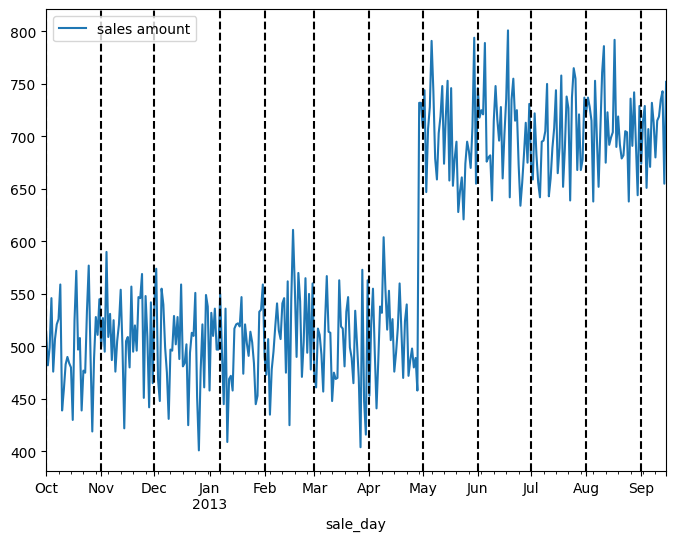

In [18]:
import matplotlib.pyplot as plt

fig_size=(8,6)
ax = daily_sales_df.plot(x='sale_day', y='sales amount', figsize=fig_size)
xcoords = ['2012-10-01','2012-11-01','2012-12-01',
           '2013-01-07', '2013-02-01','2013-03-01', 
           '2013-04-01', '2013-05-01', '2013-06-01', 
           '2013-07-01', '2013-08-01', '2013-09-01']
for xc in xcoords:
    plt.axvline(x=xc, color='black', linestyle='--')

It doesn't seem the sales amount has a clear correlation with months.

We analyzed our dataset from different perspectives. Now, we are ready to continue with questions.

## Question 1: Plot daily sales for all 50 weeks.

We will produce a plot similar to the one we used to check the trends above. We won't mark the months this time. Pandas plot( ) function provides us with the ability to plot the data without using another library. By default, it uses the dataset index as the x-axis and other columns as y-axis values. Our daily_sales_df index will be sale_day which are the days on which sales occur. The only column of daily_sales_df will be sales_amount which we calculated before. This is one of the alternative methods to plot. plot( ) function also provides flexibility to choose axis columns when we have multiple columns in the dataset.

<function matplotlib.pyplot.show(close=None, block=None)>

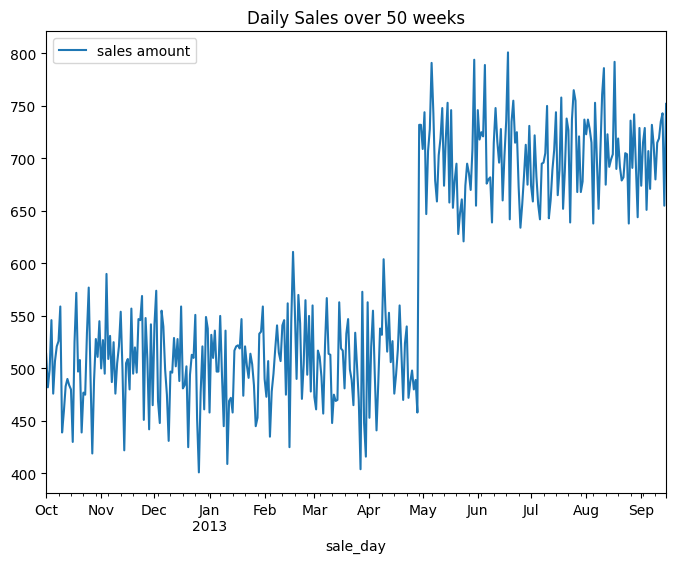

In [19]:
import matplotlib.pyplot as plt

fig_size=(8,6)

if 'sale_day' in daily_sales_df.columns:
    daily_sales_df.set_index('sale_day', inplace=True)

daily_sales_df.plot(figsize=fig_size, title='Daily Sales over 50 weeks')
plt.show

We plotted the daily sales over to 50 weeks and observe a sudden change around May

## Question 2: It looks like there has been a sudden change in daily sales. What date did it occur?

This question is interested in the sudden change we observed in the plot above. To be able to say the exact date this change occurred, we need to compare the sales amount difference with the previous day and find the biggest difference which should give us the sudden change in the sales amount. Since we do not know the previous day data of the first row in our data set, we can use None instead of. Also, our last sales_amount is the previous day's sales amount of a date (2013-09-15) not in the dataset, so we won't use it.

In [21]:
daily_sales_df['prev_day_sale_amount'] = daily_sales_df['sales amount'].shift(1)
daily_sales_df['difference_btw_prev_day'] = daily_sales_df['sales amount'] - daily_sales_df['prev_day_sale_amount']
daily_sales_df.head()

,sales amount,prev_day_sale_amount,difference_btw_prev_day
sale_day,,,
2012-10-01,514,NaN,NaN
2012-10-02,482,514.0,-32.0
2012-10-03,499,482.0,17.0
2012-10-04,546,499.0,47.0
2012-10-05,476,546.0,-70.0


We see 'NaN' values in the first row. Pandas interprets Python 'None' value as NaN. Since we obtained the difference between days, we can get the maximum difference and see its index, which is the date that the sales amount occurred. idxmax( ) function returns the index of max value in given column.

In [23]:
# get the index of max change to answer what date did it occur
max_value = daily_sales_df['difference_btw_prev_day'].max()
daily_sales_df[daily_sales_df['difference_btw_prev_day']==max_value]

,sales amount,prev_day_sale_amount,difference_btw_prev_day
sale_day,,,
2013-04-29,732,458.0,274.0


The date of sudden change is '2013-04-29'. By using this date as an index, we can get the sales amount at this particular date.

## Question 3: Is the change in daily sales at the date you selected statistically significant? If so, what is the p-value?

Statistical significance is decided by a t-test in statistics. If you want to learn more about different kinds of statistical analysis and each of their use cases, you can read more here. Scipy, a library that implements several scientific concepts in Python, includes a stats module to apply t-test. We want to understand the importance of a specific sample, so we'll use _ttestlsamp( ) function.

In [31]:
from scipy import stats

# Define the date at which the largest change in daily sales was observed
change_date = '2013-04-29'

# Split the dataset into two groups: one before the change date and one after (inclusive)
# Since the DataFrame index contains datetime values, direct comparison is valid
before = daily_sales_df[daily_sales_df.index < change_date]['sales amount']
after = daily_sales_df[daily_sales_df.index >= change_date]['sales amount']

# Perform a two-sample Welch’s t-test to evaluate whether the difference 
# in average daily sales between the two periods is statistically significant.
# We assume unequal variance between the two groups by setting equal_var=False
t_stat, p_value = stats.ttest_ind(before, after, equal_var=False)
print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -45.943533193935615
p-value: 3.487246853115062e-138


The obtained p-value as the result of the two-sample t-test is 3.81e-138, which is significantly lower than the conventional threshold of 0.05. This extremely small p-value provides strong statistical evidence that the difference in daily sales before and after the change date is not due to random chance. Therefore, we can confidently conclude that this particular date marks a statistically significant shift in sales behavior, and it is indeed important for further analysis.

## Question 4: Does the data suggest that the change in daily sales is due to a shift in the proportion of male-vs-female customers? Please use plots to support your answer (a rigorous statistical analysis is not necessary).

This question implies a dramatic change might have happened in male-vs-female customers at the date of sudden change. We can observe whether this assumption is valid or not by plotting sales amounts with gender portions over 50 weeks. We will aggregate our initial dataset, which includes the purchaser_gender column, first by sale_day then purchaser_gender. It returns us daily sales amount by gender.

In [33]:
# create gender_portions_df to analyze sales distribution over genders
combined_df['sale_day'] = pd.to_datetime(combined_df['sale_time']).dt.floor('d')
gender_portions_df = combined_df.groupby(['sale_day', 'purchaser_gender']).size().reset_index(name = 'sales_amount')
gender_portions_df

,sale_day,purchaser_gender,sales_amount
0,2012-10-01,female,413
1,2012-10-01,male,101
2,2012-10-02,female,379
3,2012-10-02,male,103
4,2012-10-03,female,386
...,...,...,...
695,2013-09-13,male,537
696,2013-09-14,female,193
697,2013-09-14,male,462
698,2013-09-15,female,230


After filtering the previous dataset by female and male genders, we can obtain female_sales_amount and male_sales_amount columns for each day.

In [36]:
new_df = pd.DataFrame(gender_portions_df['sale_day'].unique(), columns=['sale_day'])
new_df['female_sales_amount'] = pd.Series(gender_portions_df[gender_portions_df['purchaser_gender'] == 'female']['sales_amount']).reset_index(drop=True)
new_df['male_sales_amount'] = pd.Series(gender_portions_df[gender_portions_df['purchaser_gender'] == 'male']['sales_amount']).reset_index(drop=True)

With our new columns, we divide male_sales_amount to female_sales_amount to calculate the gender ratio among customers per day.

In [37]:
# calculate gender ratio of sales
new_df['gender_ratio'] = new_df['male_sales_amount'] / new_df['female_sales_amount']
new_df.head()

,sale_day,female_sales_amount,male_sales_amount,gender_ratio
0,2012-10-01,413,101,0.244552
1,2012-10-02,379,103,0.271768
2,2012-10-03,386,113,0.292746
3,2012-10-04,432,114,0.263889
4,2012-10-05,368,108,0.293478


Now, we will plot gender ratio change over 50 weeks with the total sales amount to observe if there is a correlation between them. _secondaryy argument of plot( ) function solves the problem of having two different scales in one plot. It rescales the secondary y with a new y-axis on the right side of the plot.

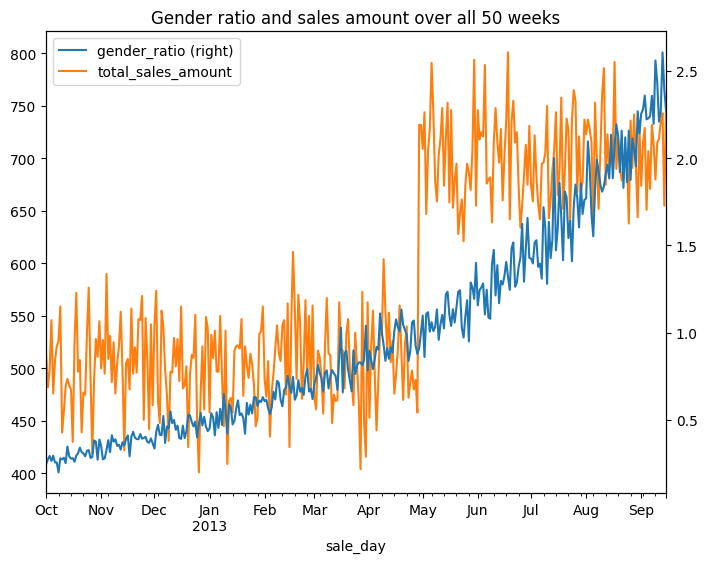

In [39]:
FIG_SIZE = (8,6)
# copy() function creates a new dataframe as a copy of the given dataframe
plot_df = new_df.copy()
plot_df['total_sales_amount'] = plot_df['female_sales_amount'] + plot_df['male_sales_amount']

# do not need anymore sales amounts by gender,we used them to calculate gender ratio
plot_df.drop(columns=['female_sales_amount', 'male_sales_amount'], inplace=True)
plot_df.index = plot_df['sale_day']
plot_df.drop(columns=['sale_day'], inplace=True)
plot_df.plot(secondary_y = ['gender_ratio'],figsize=FIG_SIZE, title= "Gender ratio and sales amount over all 50 weeks")
plt.show()

The increasing trend of the male ratio in the sales amount does not explain the sudden change. The reason should be something different. For example, it might be caused by starting a new marketing campaign or adding a new feature to the website.

# Question 5: Assume a given day is divided into four dayparts: night (12:00AM - 6:00AM), morning (6:00AM to 12:00PM), afternoon (12:00PM to 6:00PM) and evening (6:00PM - 12:00AM). What is the percentage of sales in each daypart over all 50 weeks?

To understand the sales amount distribution over particular parts of the day, we need to calculate specific sales amounts within mentioned parts. Again, pandas DateTime datatype helps us to get hours in timestamps so we can divide the day into parts according to hours. Therefore, we start with changing the initial dataset sale_time column to the DateTime object. We can check the data types with .dtypes.

In [49]:
combined_df['sale_hour'] = combined_df['sale_time'].dt.hour
combined_df.dtypes

sale_time           datetime64[ns]
purchaser_gender            object
Time                        object
sale_day            datetime64[ns]
sale_hour                    int32
dtype: object

In [50]:
# define a function to apply sale hour column to decide a part of day based on the mentioned logic
def assign_day_part(sale_hour):
    if sale_hour >= 6 and sale_hour < 12:
        return 'morning'
    if sale_hour >= 12 and sale_hour < 18:
        return 'afternoon'
    if sale_hour >= 18 and sale_hour < 24:
        return 'evening'
    if sale_hour >= 0 and sale_hour < 6:
        return 'night'

In [51]:
combined_df

,sale_time,purchaser_gender,Time,sale_day,sale_hour
0,2013-02-25 00:40:45,male,00:40:45,2013-02-25,0
1,2013-02-25 00:56:52,male,00:56:52,2013-02-25,0
2,2013-02-25 01:18:00,female,01:18:00,2013-02-25,1
3,2013-02-25 01:20:00,male,01:20:00,2013-02-25,1
4,2013-02-25 01:45:08,female,01:45:08,2013-02-25,1
...,...,...,...,...,...
204324,2013-05-05 22:43:55,female,22:43:55,2013-05-05,22
204325,2013-05-05 22:52:03,male,22:52:03,2013-05-05,22
204326,2013-05-05 22:57:44,female,22:57:44,2013-05-05,22
204327,2013-05-05 23:31:56,male,23:31:56,2013-05-05,23


In [52]:
# apply the defined function and create day_part column
combined_df['day_part'] = combined_df['sale_hour'].apply(assign_day_part)
# drop unnecessary columns
combined_df.drop(columns = ['Time', 'purchaser_gender', 'sale_hour', 'sale_time'], inplace= True)
combined_df

,sale_day,day_part
0,2013-02-25,night
1,2013-02-25,night
2,2013-02-25,night
3,2013-02-25,night
4,2013-02-25,night
...,...,...
204324,2013-05-05,evening
204325,2013-05-05,evening
204326,2013-05-05,evening
204327,2013-05-05,evening


In [53]:
# We can check some entries with different parts of the day.

combined_df[combined_df.day_part == 'afternoon']

,sale_day,day_part
216,2013-02-25,afternoon
217,2013-02-25,afternoon
218,2013-02-25,afternoon
219,2013-02-25,afternoon
220,2013-02-25,afternoon
...,...,...
204188,2013-05-05,afternoon
204189,2013-05-05,afternoon
204190,2013-05-05,afternoon
204191,2013-05-05,afternoon


The only remaining step to answer the question is, calculating the total sales amount per day part. We will use the groupby( ) function one last time to obtain the total sales amount by day parts. Then we can divide each day part sales amount by the total sales amount for all 50 weeks. We obtain the total sales amount with the sum( ) function.

In [54]:
# calculate sales amount per day part
df_pct_sales = combined_df.groupby(combined_df['day_part']).size().reset_index(name='day_part_sales_amount')

# calculate sales amount percentage per day part
df_pct_sales['day_part_sales_percentage'] = df_pct_sales['day_part_sales_amount'] / df_pct_sales['day_part_sales_amount'].sum()

In [55]:
df_pct_sales

,day_part,day_part_sales_amount,day_part_sales_percentage
0,afternoon,80533,0.394134
1,evening,42620,0.208585
2,morning,62870,0.307690
3,night,18306,0.089591


In conclusion, we can say the customers of this company do more shopping in the afternoon and very less shopping at nights.